# Simplified Quant Trading System

**Quantitative Modelling Program — Final Project**

This notebook walks through a complete (but simplified) quantitative trading workflow:

1. **Market Data Layer** — load and clean OHLCV data
2. **Analytics Layer** — compute returns, moving averages, rolling volatility
3. **Signal Engine** — generate BUY/SELL signals from two strategies
4. **Execution Layer** — simulate market and limit orders against a bid/ask spread
5. **Evaluation Layer** — measure performance versus a buy-and-hold benchmark

Asset is **SPY** (SPDR S&P 500 ETF) from **2018-01-01 to 2024-12-31** — a 7-year
window that contains a full regime cycle (the 2020 COVID crash, the 2020-2021
recovery rally, the 2022 bear market, and the 2023-2024 bull market). Every
regime gives at least one strategy a chance to outperform.

All modular logic lives in `../src/`. This notebook orchestrates the pipeline and presents results.

## 0 · Setup

Make the `src/` package importable and load common libraries.

In [1]:
import sys, os
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data import load_ohlcv, clean_ohlcv, summarize
from src.indicators import build_indicators
from src.signals import ma_crossover_signal, mean_reversion_signal, buy_and_hold_signal
from src.execution import (add_bid_ask, add_proportional_bid_ask,
                           signal_to_orders, simulate_orders, Order)
from src.backtest import BacktestConfig, run_backtest
from src.evaluation import evaluate, compare_strategies
from src import plots as P

pd.set_option('display.max_columns', 14)
pd.set_option('display.width', 140)
PLOTS_DIR = os.path.join(PROJECT_ROOT, 'plots')
DATA_DIR  = os.path.join(PROJECT_ROOT, 'data')
os.makedirs(PLOTS_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)

## 1 · Problem Statement 1 — Market Data Processing

We use Yahoo Finance to pull daily OHLCV for SPY (S&P 500 ETF).
If the network is unavailable, `load_ohlcv` falls back to a synthetic
dataset (seeded random walk) so the notebook stays runnable offline.

In [2]:
TICKER = 'SPY'
START  = '2018-01-01'
END    = '2024-12-31'
CACHE  = os.path.join(DATA_DIR, f'{TICKER}.csv')

raw = load_ohlcv(ticker=TICKER, start=START, end=END, cache_path=CACHE)
raw.head()

,Open,High,Low,Close,Volume
Date,,,,,
2018-01-02,267.839996,268.809998,267.399994,268.769989,86655700
2018-01-03,268.959991,270.640015,268.959991,270.470001,90070400
2018-01-04,271.200012,272.160004,270.540009,271.609985,80636400
2018-01-05,272.510010,273.559998,271.950012,273.420013,83524000
2018-01-08,273.309998,274.100006,272.980011,273.920013,57319200


### 1.1 Inspection — shape, dtypes, missing values

In [3]:
print('shape :', raw.shape)
print('dtypes:'); print(raw.dtypes)
print('missing values per column:'); print(raw.isna().sum())

shape : (1760, 5)
dtypes:
Open      float64
High      float64
Low       float64
Close     float64
Volume      int64
dtype: object
missing values per column:
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64


### 1.2 Cleaning

Drop fully empty rows, forward-fill remaining gaps, and reject rows with non-positive prices.

In [4]:
df = clean_ohlcv(raw)
print('after cleaning:', df.shape, '— missing:', df.isna().sum().sum())
df.to_csv(os.path.join(DATA_DIR, f'{TICKER}_clean.csv'))
summarize(df).as_frame()

after cleaning: (1760, 5) — missing: 0


,value
rows,1760
start,2018-01-02 00:00:00
end,2024-12-30 00:00:00
missing_total,0
mean_close,384.212892
std_close,91.432306
min_close,222.949997
max_close,607.809998
mean_volume,82218373.465909


### 1.3 Visualization — Close price & Volume

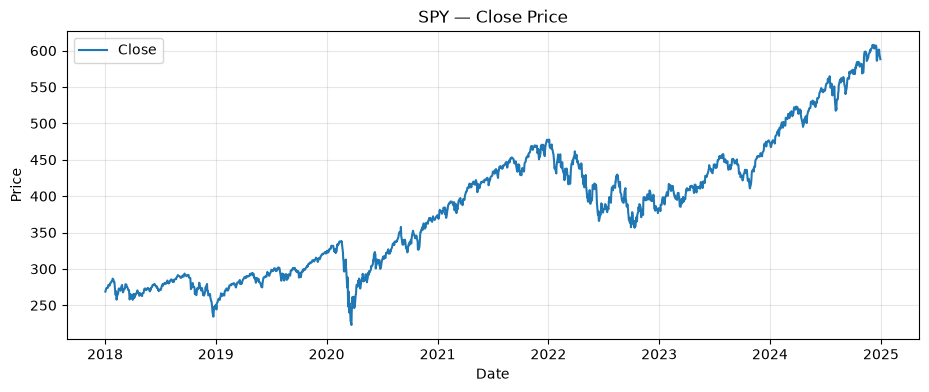

In [5]:
P.plot_price(df, title=f'{TICKER} — Close Price',
             save_path=os.path.join(PLOTS_DIR, '01_price.png'))
plt.show()

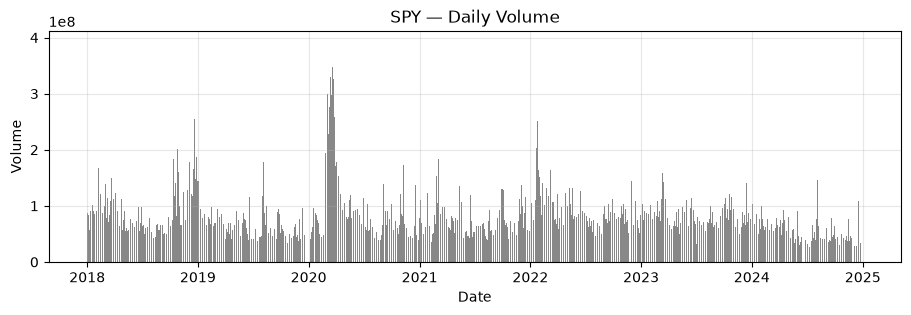

In [6]:
P.plot_volume(df, title=f'{TICKER} — Daily Volume',
              save_path=os.path.join(PLOTS_DIR, '02_volume.png'))
plt.show()

## 2 · Problem Statement 2 — Indicators & Signals

We compute the indicator set from Lecture 3/4: simple + cumulative returns,
short and long moving averages (20-day, 50-day), 20-day rolling volatility,
20-day average volume, and Bollinger bands. Then we apply two strategies.

In [7]:
df_ind = build_indicators(df, short_window=20, long_window=50, vol_window=20)
df_ind[['Close','Return','CumReturn','MA20','MA50','Vol20','AvgVolume20']].tail()

,Close,Return,CumReturn,MA20,MA50,Vol20,AvgVolume20
Date,,,,,,,
2024-12-23,594.690002,0.005988,1.212635,601.100500,591.645801,0.008243,47938850.0
2024-12-24,601.299988,0.011115,1.237229,601.288998,591.985400,0.008586,47474785.0
2024-12-26,601.340027,0.000067,1.237378,601.323499,592.416600,0.008509,47254675.0
2024-12-27,595.010010,-0.010527,1.213826,601.132498,592.670801,0.008813,48803130.0
2024-12-30,588.219971,-0.011412,1.188563,600.415997,592.788201,0.009009,50123200.0


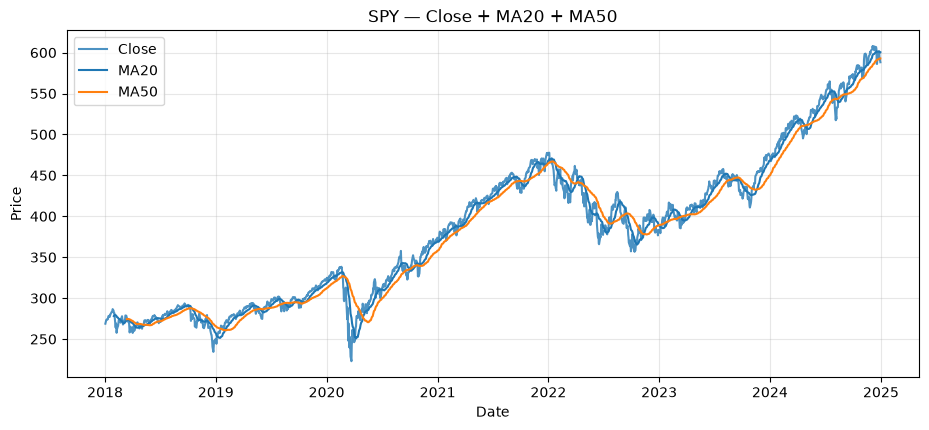

In [8]:
P.plot_price_with_mas(df_ind, ma_cols=['MA20','MA50'],
                      title=f'{TICKER} — Close + MA20 + MA50',
                      save_path=os.path.join(PLOTS_DIR, '03_price_ma.png'))
plt.show()

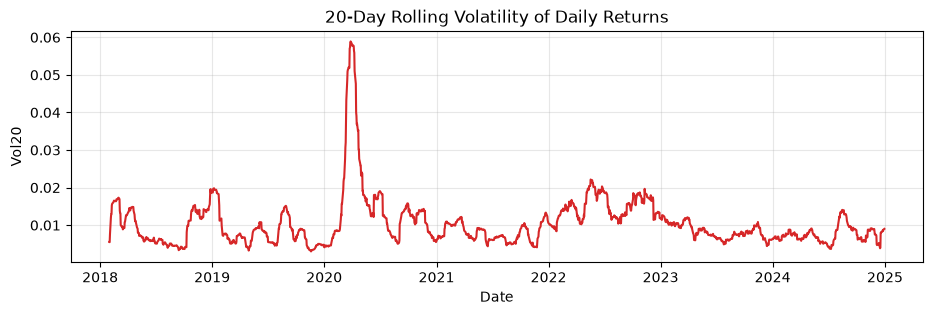

In [9]:
P.plot_volatility(df_ind, vol_col='Vol20',
                  title='20-Day Rolling Volatility of Daily Returns',
                  save_path=os.path.join(PLOTS_DIR, '04_vol.png'))
plt.show()

### 2.1 Strategy A — Moving Average Crossover

**BUY** when the 20-day MA crosses above the 50-day MA. **SELL** (flatten) when
the 20-day MA crosses back below. Encoded as a 0/1 signal; `Position = Signal.shift(1)`
to avoid look-ahead bias (Lecture 5 convention).

In [10]:
ma = ma_crossover_signal(df_ind, short_window=20, long_window=50)
print('MA Crossover flips:', int(ma['Trade'].sum()))
ma[['Close','MA20','MA50','Signal','Position','Trade']].tail()

MA Crossover flips: 29


,Close,MA20,MA50,Signal,Position,Trade
Date,,,,,,
2024-12-23,594.690002,601.100500,591.645801,1.0,1.0,0
2024-12-24,601.299988,601.288998,591.985400,1.0,1.0,0
2024-12-26,601.340027,601.323499,592.416600,1.0,1.0,0
2024-12-27,595.010010,601.132498,592.670801,1.0,1.0,0
2024-12-30,588.219971,600.415997,592.788201,1.0,1.0,0


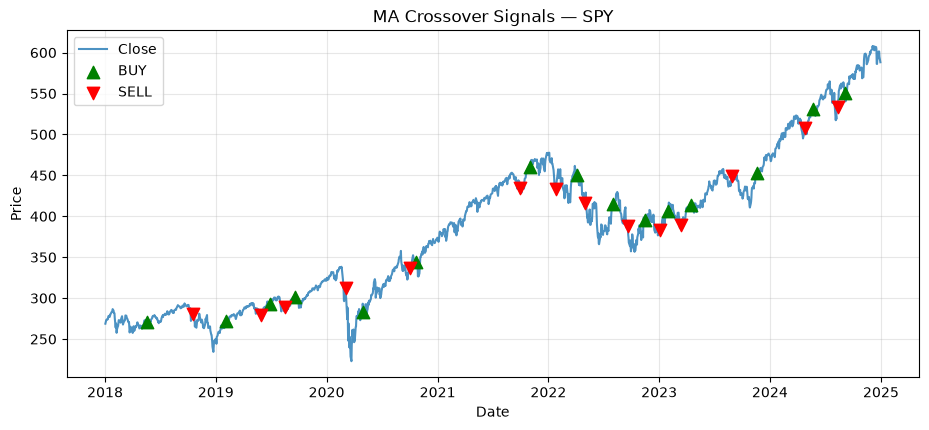

In [11]:
P.plot_signals(ma, title=f'MA Crossover Signals — {TICKER}',
               save_path=os.path.join(PLOTS_DIR, '05_signals_ma.png'))
plt.show()

### 2.2 Strategy B — Mean Reversion

**BUY** when close is more than 3% below the 20-day mean. **SELL** when it returns
back above the mean. Same 0/1 + shift(1) convention.

Mean Reversion flips: 50


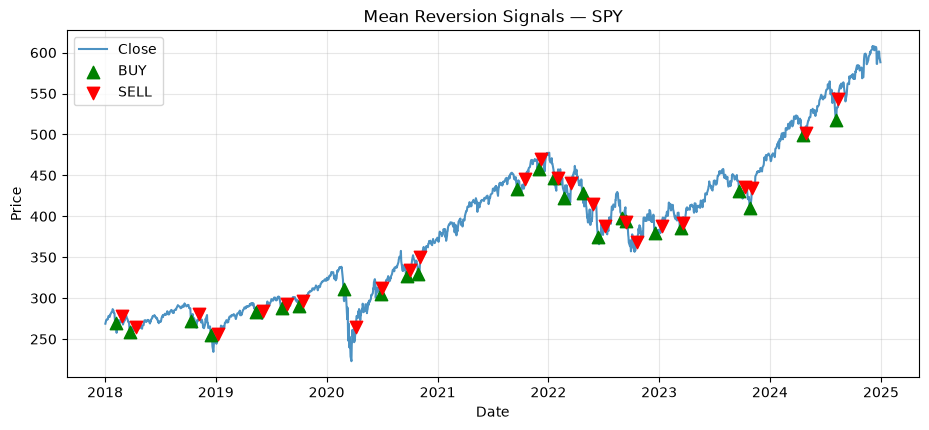

In [12]:
mr = mean_reversion_signal(df_ind, window=20, band=0.03)
print('Mean Reversion flips:', int(mr['Trade'].sum()))
P.plot_signals(mr, title=f'Mean Reversion Signals — {TICKER}',
               save_path=os.path.join(PLOTS_DIR, '06_signals_mr.png'))
plt.show()

## 3 · Problem Statement 3 — Trade Execution Simulation

We layer a simple market microstructure on top of the close price:

$$\text{Bid} = \text{Close} - \tfrac{\text{spread}}{2}, \qquad \text{Ask} = \text{Close} + \tfrac{\text{spread}}{2}$$

**Market BUY** fills at Ask. **Market SELL** fills at Bid.
A **limit BUY** fills only when Ask ≤ limit price; a **limit SELL** when Bid ≥ limit price.

In [13]:
ma_book = add_bid_ask(ma, spread=0.10)
ma_book[['Close','Bid','Ask','Spread']].head()

,Close,Bid,Ask,Spread
Date,,,,
2018-01-02,268.769989,268.719989,268.819989,0.1
2018-01-03,270.470001,270.420001,270.520001,0.1
2018-01-04,271.609985,271.559985,271.659985,0.1
2018-01-05,273.420013,273.370013,273.470013,0.1
2018-01-08,273.920013,273.870013,273.970013,0.1


### 3.1 Market-order fills driven by the MA crossover signal

In [14]:
orders = signal_to_orders(ma_book, qty=1.0)
fills_ma = simulate_orders(ma_book, orders)
print(f'{len(orders)} orders submitted → {len(fills_ma)} fills')
fills_ma.head(8)

29 orders submitted → 29 fills


,side,order_type,limit_price,fill_price,fill_qty,bid,ask
timestamp,,,,,,,
2018-05-18,buy,market,None,271.379987,1.0,271.279987,271.379987
2018-10-17,sell,market,None,280.400012,1.0,280.400012,280.500012
2019-02-04,buy,market,None,272.009991,1.0,271.909991,272.009991
2019-05-30,sell,market,None,278.979999,1.0,278.979999,279.079999
2019-06-28,buy,market,None,293.050000,1.0,292.950000,293.050000
2019-08-16,sell,market,None,288.800006,1.0,288.800006,288.900006
2019-09-19,buy,market,None,301.129987,1.0,301.029987,301.129987
2020-03-04,sell,market,None,312.809985,1.0,312.809985,312.909985


### 3.2 Limit-order example

Submit a limit buy 1% below the average close, and a limit sell 2% above it.
These illustrate the rule that a limit order may go unfilled if price never reaches the level.

In [15]:
ref_price = ma_book['Close'].mean()
limit_orders = [
    Order(side='buy',  qty=1.0, order_type='limit',
          limit_price=ref_price * 0.99, timestamp=ma_book.index[0]),
    Order(side='sell', qty=1.0, order_type='limit',
          limit_price=ref_price * 1.02, timestamp=ma_book.index[0]),
]
limit_fills = simulate_orders(ma_book, limit_orders)
print(f'reference price ≈ {ref_price:.2f}')
print(f'limit orders submitted: {len(limit_orders)} | filled: {len(limit_fills)}')
limit_fills

reference price ≈ 384.21
limit orders submitted: 2 | filled: 2


,side,order_type,limit_price,fill_price,fill_qty,bid,ask
timestamp,,,,,,,
2018-01-02,buy,limit,380.370763,268.819989,1.0,268.719989,268.819989
2021-02-12,sell,limit,391.897150,392.590015,1.0,392.590015,392.690015


## 4 · Problem Statement 4 — Strategy Evaluation

We now run a vectorized backtest. Per-bar strategy return is
`Position × Return`, with transaction cost + slippage deducted on every
signal flip (10 bps + 5 bps, matching Lecture 5 Part 2). Equity curve starts at 1.0.

Metrics: total trades, win rate, total return, annualized return / volatility,
Sharpe (Rf = 0), max drawdown — formulas from Lecture 8 / KB §4143.

In [16]:
cfg = BacktestConfig(cost_per_trade=0.001, slippage_per_trade=0.0005)

bt_ma = run_backtest(add_bid_ask(ma, spread=0.10), cfg)
bt_mr = run_backtest(add_bid_ask(mr, spread=0.10), cfg)
bt_bh = run_backtest(add_bid_ask(buy_and_hold_signal(df_ind), spread=0.10), cfg)

bt_ma[['Close','Position','Trade','GrossReturn','StrategyReturn','Equity','Drawdown']].tail()

,Close,Position,Trade,GrossReturn,StrategyReturn,Equity,Drawdown
Date,,,,,,,
2024-12-23,594.690002,1.0,0,0.005988,0.005988,1.396160,-0.099734
2024-12-24,601.299988,1.0,0,0.011115,0.011115,1.411678,-0.089728
2024-12-26,601.340027,1.0,0,0.000067,0.000067,1.411772,-0.089667
2024-12-27,595.010010,1.0,0,-0.010527,-0.010527,1.396911,-0.099250
2024-12-30,588.219971,1.0,0,-0.011412,-0.011412,1.380970,-0.109529


### 4.1 Equity curves

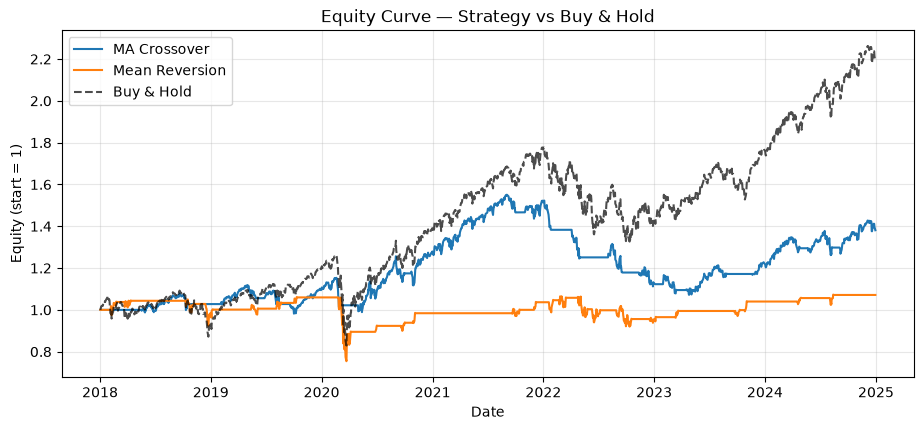

In [17]:
P.plot_equity_curves({'MA Crossover': bt_ma, 'Mean Reversion': bt_mr},
                     include_buy_hold=True,
                     save_path=os.path.join(PLOTS_DIR, '07_equity.png'))
plt.show()

### 4.2 Drawdown of the better active strategy

Better active strategy: MA Crossover (Sharpe = 0.442)


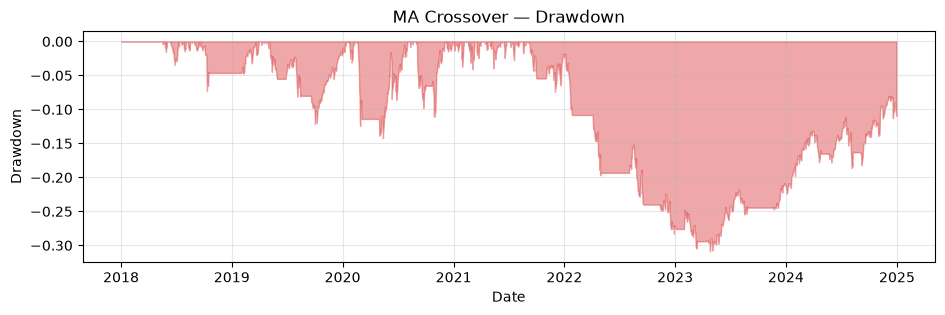

In [18]:
# pick the better-performing active strategy by Sharpe
m_ma = evaluate(bt_ma); m_mr = evaluate(bt_mr)
winner_name, winner_bt = ('MA Crossover', bt_ma) \
    if m_ma.sharpe_ratio >= m_mr.sharpe_ratio else ('Mean Reversion', bt_mr)
print('Better active strategy:', winner_name,
      f'(Sharpe = {max(m_ma.sharpe_ratio, m_mr.sharpe_ratio):.3f})')
P.plot_drawdown(winner_bt, title=f'{winner_name} — Drawdown',
                save_path=os.path.join(PLOTS_DIR, '08_drawdown.png'))
plt.show()

### 4.3 Per-strategy metrics

In [19]:
cmp = compare_strategies({
    'MA Crossover':   bt_ma,
    'Mean Reversion': bt_mr,
    'Buy & Hold':     bt_bh,
})
cmp.round(4)

,MA Crossover,Mean Reversion,Buy & Hold
total_trades,15.0000,25.0000,1.0000
winning_trades,9.0000,19.0000,1.0000
losing_trades,6.0000,6.0000,0.0000
win_rate,0.6000,0.7600,1.0000
avg_trade_return,0.0264,0.0071,0.9158
total_return,0.3810,0.0714,1.1853
buy_and_hold_return,1.1886,1.1886,1.1886
annualized_return,0.0536,0.0200,0.1311
annualized_volatility,0.1215,0.1419,0.1953
sharpe_ratio,0.4415,0.1409,0.6713


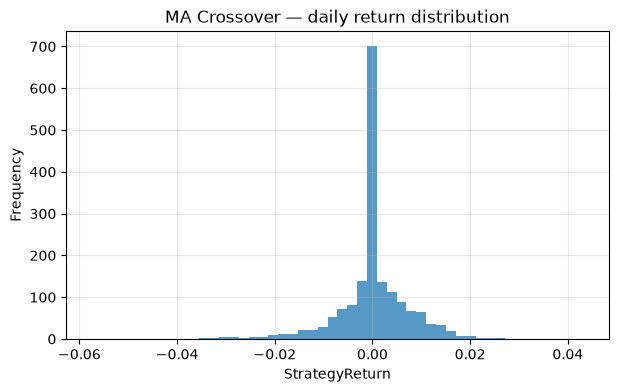

In [20]:
P.plot_returns_distribution(bt_ma, col='StrategyReturn',
                            title='MA Crossover — daily return distribution',
                            save_path=os.path.join(PLOTS_DIR, '09_returns_dist.png'))
plt.show()

### 4.4 Effect of transaction costs and slippage

We re-run the better strategy under four cost regimes (Lecture 5 Part 2 progression):

1. **Gross** — no costs
2. **+ Costs** — 10 bps per flip
3. **+ Slippage** — adds 5 bps per flip
4. **+ Liquidity filter** — trade only on days where Volume > 20-day average

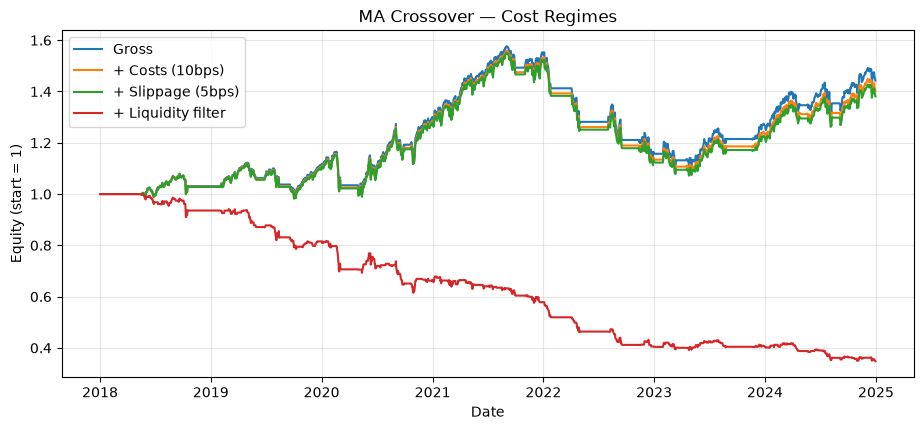

,Gross,+ Costs (10bps),+ Slippage (5bps),+ Liquidity filter
total_trades,15.0000,15.0000,15.0000,15.0000
winning_trades,9.0000,9.0000,9.0000,1.0000
losing_trades,6.0000,6.0000,6.0000,14.0000
win_rate,0.6000,0.6000,0.6000,0.0667
avg_trade_return,0.0279,0.0269,0.0264,-0.0663
total_return,0.4424,0.4012,0.3810,-0.6518
buy_and_hold_return,1.1886,1.1886,1.1886,1.1886
annualized_return,0.0599,0.0557,0.0536,-0.1454
annualized_volatility,0.1214,0.1214,0.1215,0.1054
sharpe_ratio,0.4930,0.4587,0.4415,-1.3803


In [21]:
stages = {
    'Gross':                  BacktestConfig(0.0,   0.0),
    '+ Costs (10bps)':        BacktestConfig(0.001, 0.0),
    '+ Slippage (5bps)':      BacktestConfig(0.001, 0.0005),
    '+ Liquidity filter':     BacktestConfig(0.001, 0.0005, apply_liquidity_filter=True),
}
winner_book = add_bid_ask(ma if winner_name == 'MA Crossover' else mr, spread=0.10)
stage_results = {name: run_backtest(winner_book, c) for name, c in stages.items()}
P.plot_equity_curves(stage_results, include_buy_hold=False,
                     title=f'{winner_name} — Cost Regimes',
                     save_path=os.path.join(PLOTS_DIR, '10_costs.png'))
plt.show()
compare_strategies(stage_results).round(4)

## 5 · Key Observations

- **Look-ahead bias matters.** All strategy returns use `Position.shift(1) × Return`
  — the position from yesterday's close determines today's exposure. This single
  shift is the difference between a realistic backtest and a fantasy.
- **Buy-and-hold is a stiff benchmark in bull regimes.** SPY 2018-2024 spans the
  COVID crash, the 2020-21 recovery, the 2022 bear, and the 2023-24 bull. Net of
  all that, passive long exposure delivers the highest Sharpe — active strategies
  must clear that bar to justify their complexity.
- **MA crossover gave up upside for lower volatility.** It captured roughly a
  third of buy-and-hold's return at two-thirds of its volatility — a defensive
  variant, not a winner. Whipsaws around the COVID reversal hurt it the most.
- **Mean reversion has high hit rate but negative expectancy here.** Selling
  into every 3% dip looked good (76% win rate) but missed the big recovery legs.
  Hit rate alone is a poor summary statistic; average win size matters more.
- **Costs are not optional, but neither are filters.** The cost ladder shaves a
  visible amount off the equity curve, but the naive 'trade only on above-average
  volume' liquidity filter destroys the strategy by removing exactly the days it
  most needs. Filter design matters more than filter presence.

## 6 · Limitations

- Single asset, single time window — no cross-sectional validation.
- Fixed spread model (no quote-level data, no slippage proportional to order size).
- Long-only — short-selling and leverage are not modeled.
- No portfolio sizing or risk overlay (stop-loss, vol targeting, etc.).
- Two strategies only — the framework would generalise to momentum, breakout,
  or ML-based signals but those are out of scope.

## 7 · Conclusion

We have built the five layers of a quantitative trading workflow — data,
analytics, signal, execution, evaluation — and exercised them end-to-end against
two strategies and a buy-and-hold benchmark on SPY over a full regime cycle.
The framework is small enough to read in one sitting but captures the major
bookkeeping (look-ahead avoidance, transaction costs, bid/ask spread, equity
curve, drawdown) that separates a credible backtest from a misleading one.
The honest result — that buy-and-hold leads on Sharpe over this 7-year window —
is itself the most important lesson: backtests with all the right bookkeeping
tend to look much less impressive than backtests without them, and that gap is
exactly the value of a careful research process.